# Chebyshev-based mean-field calculations for large systems

`h.get_mean_field_hamiltonian_kpm` solves the same selfconsistency problem as
`get_mean_field_hamiltonian`, but obtains the density matrix from a per-k Chebyshev-moment (Kernel
Polynomial Method) expansion instead of exact diagonalization of the Bloch Hamiltonian, useful once
the system is too large/sparse for dense diagonalization to be the bottleneck. Below it is
cross-checked directly against exact diagonalization on a small honeycomb flake, for both an onsite
$U$ and a first-neighbor $V_1$ interaction.

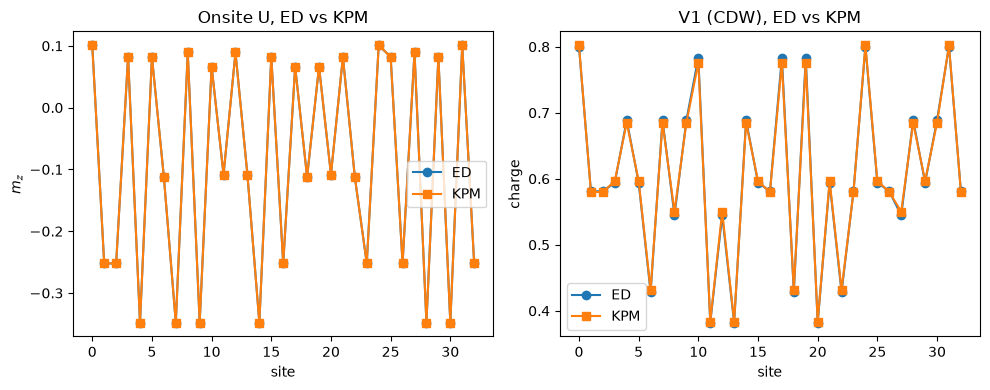

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import islands

def flake():
    return islands.get_geometry(name="honeycomb",n=2,nedges=3).get_hamiltonian()

common = dict(maxerror=1e-4,mix=0.5,maxite=300,verbose=0)

# onsite U, ferromagnetic guess
hed_u,_ = flake().get_mean_field_hamiltonian(filling=0.5,U=1.5,mf="ferro",**common,return_total_energy=True)
hkpm_u,_ = flake().get_mean_field_hamiltonian_kpm(filling=0.5,U=1.5,mf="ferro",npol=200,**common,return_total_energy=True)

# first-neighbor V1, seeded with a sublattice-imbalance (CDW) guess.
# This small, highly symmetric triangular flake has an exactly 6-fold
# degenerate single-particle level; filling=0.25 would land the target
# electron count exactly inside that degeneracy, where ED's and KPM's
# independent Fermi-level searches can settle on opposite sides of the
# tie (a demo/finite-size pathology, not a KPM bug -- see
# tests/scf/test_densitydensity_kpm.py for a generic ED-vs-KPM
# agreement check). filling=0.3 falls in a real gap instead.
h0 = flake() ; h0.add_sublattice_imbalance(0.2)
hed_v,_ = flake().get_mean_field_hamiltonian(filling=0.3,V1=1.0,mf=h0,**common,return_total_energy=True)
hkpm_v,_ = flake().get_mean_field_hamiltonian_kpm(filling=0.3,V1=1.0,mf=h0,npol=200,**common,return_total_energy=True)

fig,axs = plt.subplots(1,2,figsize=(10,4))
axs[0].plot(hed_u.get_magnetization()[:,2],marker="o",label="ED")
axs[0].plot(hkpm_u.get_magnetization()[:,2],marker="s",label="KPM")
axs[0].set_xlabel("site") ; axs[0].set_ylabel("$m_z$") ; axs[0].legend()
axs[0].set_title("Onsite U, ED vs KPM")
axs[1].plot(hed_v.get_vev(),marker="o",label="ED")
axs[1].plot(hkpm_v.get_vev(),marker="s",label="KPM")
axs[1].set_xlabel("site") ; axs[1].set_ylabel("charge") ; axs[1].legend()
axs[1].set_title("V1 (CDW), ED vs KPM")
plt.tight_layout()
plt.show()

The same comparison as a real-space map: the self-consistent magnetization and charge on every
site of the flake, from exact diagonalization and from the KPM, which come out on top of each
other.

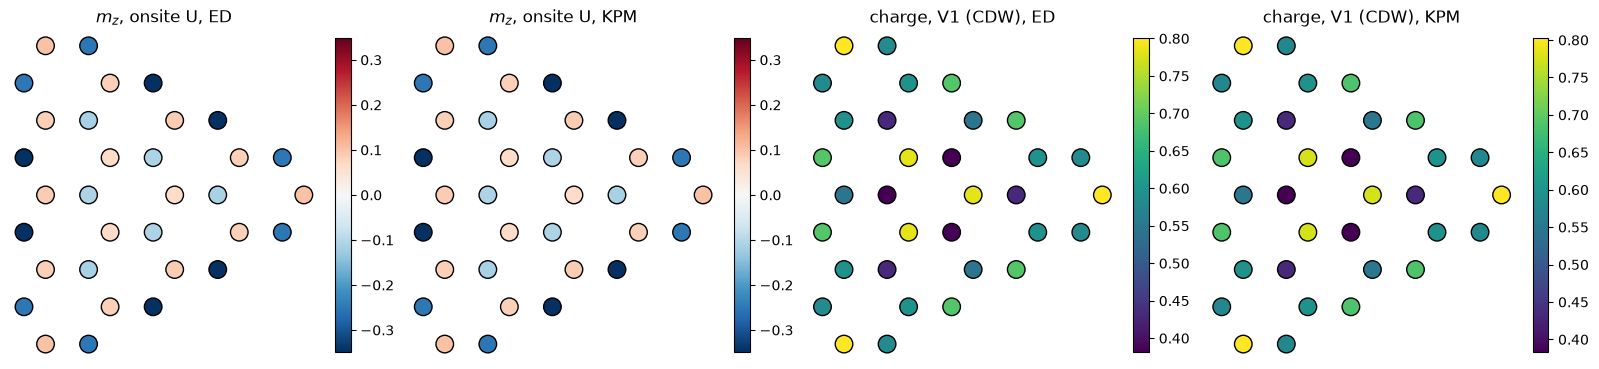

In [2]:
r = hed_u.geometry.r # positions of the sites of the flake
maps = [(hed_u.get_magnetization()[:,2],"$m_z$, onsite U, ED","RdBu_r"),
        (hkpm_u.get_magnetization()[:,2],"$m_z$, onsite U, KPM","RdBu_r"),
        (hed_v.get_vev(),"charge, V1 (CDW), ED","viridis"),
        (hkpm_v.get_vev(),"charge, V1 (CDW), KPM","viridis")]
fig,axs = plt.subplots(1,4,figsize=(16,3.8))
for ax,(m,title,cmap) in zip(axs,maps):
    if cmap=="RdBu_r": vmax = np.max(np.abs(m)) ; vmin = -vmax # symmetric scale for the moment
    else: vmin,vmax = None,None
    sc = ax.scatter(r[:,0],r[:,1],c=m,cmap=cmap,s=160,vmin=vmin,vmax=vmax,edgecolors="k")
    plt.colorbar(sc,ax=ax,fraction=0.046)
    ax.set_aspect("equal") ; ax.axis("off") ; ax.set_title(title)
plt.tight_layout()
plt.show()